Tugas 2
Nama  : Rifki Abdillah Al Afif
Nim   : 2411512027
Kelas : A

In [2]:
import threading
import time

saldo_tanpa_lock = 1_000_000
saldo_dengan_lock = 1_000_000
lock = threading.Lock()

def transaksi_tanpa_lock(jumlah_iterasi):
    global saldo_tanpa_lock
    for _ in range(jumlah_iterasi):
        temp = saldo_tanpa_lock
        temp -= 1
        time.sleep(0)
        temp += 1
        saldo_tanpa_lock = temp

def transaksi_dengan_lock(jumlah_iterasi):
    global saldo_dengan_lock
    for _ in range(jumlah_iterasi):
        with lock:
            temp = saldo_dengan_lock
            temp -= 1
            time.sleep(0)
            temp += 1
            saldo_dengan_lock = temp

JUMLAH_THREAD = 10
JUMLAH_ITERASI = 10_000

threads_1 = [threading.Thread(target=transaksi_tanpa_lock, args=(JUMLAH_ITERASI,)) for _ in range(JUMLAH_THREAD)]
for t in threads_1:
    t.start()
for t in threads_1:
    t.join()

threads_2 = [threading.Thread(target=transaksi_dengan_lock, args=(JUMLAH_ITERASI,)) for _ in range(JUMLAH_THREAD)]
for t in threads_2:
    t.start()
for t in threads_2:
    t.join()

print("=== HASIL NOMOR 1 ===")
print(f"Saldo Awal                   : 1,000,000")
print(f"Saldo Akhir (Tanpa Lock)     : {saldo_tanpa_lock:,}")
print(f"Saldo Akhir (Dengan Lock)    : {saldo_dengan_lock:,}")

=== HASIL NOMOR 1 ===
Saldo Awal                   : 1,000,000
Saldo Akhir (Tanpa Lock)     : 1,000,000
Saldo Akhir (Dengan Lock)    : 1,000,000


Berdasarkan percobaan yang dilakukan beberapa kali, hasil saldo akhir pada program tanpa Lock maupun dengan Lock tetap sebesar Rp1.000.000. Hasil tersebut terjadi karena race condition tidak selalu muncul pada setiap eksekusi. Perbedaan hasil sangat bergantung pada penjadwalan thread oleh sistem saat program dijalankan.

Pada program dengan Lock, akses terhadap saldo diatur sehingga hanya satu thread yang dapat mengubah saldo pada satu waktu. Sedangkan pada program tanpa Lock, meskipun terdapat kemungkinan race condition, pada percobaan ini kondisi tersebut tidak menyebabkan perubahan pada hasil akhir. Oleh karena itu, kedua program menghasilkan saldo yang sama, tetapi penggunaan Lock tetap penting untuk menjaga konsistensi data ketika beberapa thread mengakses data yang sama.

In [5]:
import threading
import queue
import time
import random

def producer(q, jumlah_item, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.05, 0.1))
        q.put(item)
        print(f"[{nama}] menghasilkan: {item}")
    
    for _ in range(3):
        q.put(None)

def consumer(q, nama="Consumer"):
    while True:
        item = q.get()
        if item is None:
            q.task_done()
            break
        time.sleep(random.uniform(0.05, 0.15))
        print(f"    [{nama}] memproses: {item}")
        q.task_done()

q = queue.Queue()

t_producer = threading.Thread(target=producer, args=(q, 12))
consumers = [threading.Thread(target=consumer, args=(q,), name=f"Consumer-{i+1}") for i in range(3)]

t_producer.start()
for c in consumers:
    c.start()

t_producer.join()
for c in consumers:
    c.join()

print("\nSemua item telah diproduksi dan dikonsumsi oleh 3 consumer dengan sukses.")

[Producer] menghasilkan: item-0
[Producer] menghasilkan: item-1
    [Consumer] memproses: item-0
[Producer] menghasilkan: item-2
    [Consumer] memproses: item-1
[Producer] menghasilkan: item-3
    [Consumer] memproses: item-2
[Producer] menghasilkan: item-4
    [Consumer] memproses: item-3
[Producer] menghasilkan: item-5
    [Consumer] memproses: item-4
[Producer] menghasilkan: item-6
    [Consumer] memproses: item-6
    [Consumer] memproses: item-5
[Producer] menghasilkan: item-7
[Producer] menghasilkan: item-8
    [Consumer] memproses: item-7
[Producer] menghasilkan: item-9
    [Consumer] memproses: item-8
[Producer] menghasilkan: item-10
    [Consumer] memproses: item-9
[Producer] menghasilkan: item-11
    [Consumer] memproses: item-10
    [Consumer] memproses: item-11

Semua item telah diproduksi dan dikonsumsi oleh 3 consumer dengan sukses.


max_workers =  2 | Waktu Eksekusi: 5.94 detik
max_workers =  4 | Waktu Eksekusi: 3.04 detik
max_workers =  8 | Waktu Eksekusi: 1.63 detik
max_workers = 16 | Waktu Eksekusi: 0.92 detik


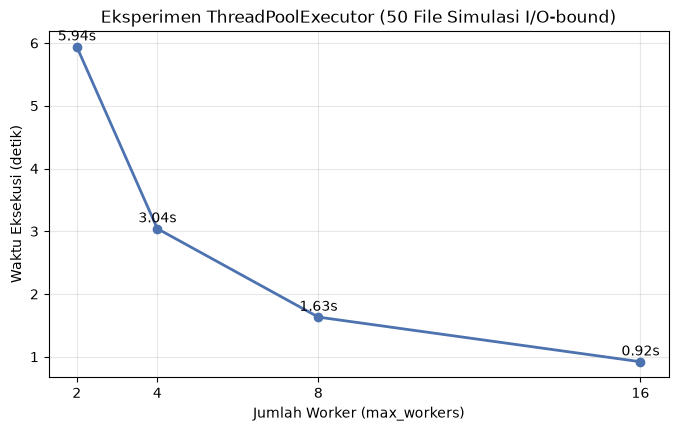

In [6]:
import time
import random
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

random.seed(42)
daftar_file_50 = [f"file_{i}.dat" for i in range(50)]
latensi_simulasi_50 = {f: random.uniform(0.1, 0.4) for f in daftar_file_50}

def download_file_50(nama_file):
    durasi = latensi_simulasi_50[nama_file]
    time.sleep(durasi)
    return f"{nama_file} selesai"

worker_list = [2, 4, 8, 16]
waktu_eksekusi = []

for workers in worker_list:
    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as executor:
        list(executor.map(download_file_50, daftar_file_50))
    elapsed = time.perf_counter() - start
    waktu_eksekusi.append(elapsed)
    print(f"max_workers = {workers:2d} | Waktu Eksekusi: {elapsed:.2f} detik")

plt.figure(figsize=(8, 4.5))
plt.plot(worker_list, waktu_eksekusi, marker='o', color='#4C72B0', linewidth=2)
plt.title("Eksperimen ThreadPoolExecutor (50 File Simulasi I/O-bound)")
plt.xlabel("Jumlah Worker (max_workers)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.xticks(worker_list)
plt.grid(True, alpha=0.3)

for x, y in zip(worker_list, waktu_eksekusi):
    plt.text(x, y + 0.1, f"{y:.2f}s", ha='center')

plt.show()

Berdasarkan grafik hasil pengujian ThreadPoolExecutor pada 50 file simulasi, peningkatan jumlah max_workers dari 2 ke 4 dan 8 secara signifikan mampu memangkas total waktu eksekusi dari 5.94 detik menjadi 3.04 detik hingga mencapai 1.63 detik. Hal ini membuktikan bahwa penambahan worker sangat efektif untuk mempercepat pemrosesan tugas yang bersifat I/O-bound, karena thread yang sedang menunggu simulasi latensi dapat mengalihkan giliran ke thread lain yang siap berjalan. Namun, ketika jumlah worker ditingkatkan lebih lanjut ke angka 16, waktu eksekusi hanya berkurang sedikit menjadi 0.92 detik dan grafik mulai melandai mendekati titik jenuh. Penambahan jumlah worker secara terus-menerus tidak akan selalu memberikan percepatan yang linier karena adanya overhead tambahan yang ditanggung oleh sistem operasi untuk mengalokasikan memori, mengelola pembuatan thread, serta melakukan perpindahan konteks (context switching). Selain itu, pada kasus nyata, kecepatan batas eksekusi I/O-bound pada akhirnya akan dibatasi oleh faktor eksternal seperti lebar pita jaringan (bandwidth) atau limitasi respon dari server tujuan, bukan lagi oleh jumlah thread lokal yang dibuat.

4. salah satu contoh kasus nyata di mana threading Python akan membantu, dan satu contoh kasus di mana threading Python tidak akan membantu adalah Penerapan threading pada Python yang memberikan dampak efisiensi yang sangat tinggi pada kasus web scraping atau pengambilan data dari puluhan halaman web secara simultan. Tugas ini tergolong ke dalam kategori I/O-bound karena sebagian besar waktu proses dihabiskan hanya untuk menunggu respon jaringan dari server sasaran (network latency). Saat thread berada dalam posisi menunggu I/O, Python secara otomatis melepaskan Global Interpreter Lock (GIL) sehingga thread lain dapat langsung dieksekusi tanpa tertahan, yang pada akhirnya memangkas total waktu eksekusi secara drastis. Sebaliknya, penggunaan threading sama sekali tidak memberikan percepatan pada kasus komputasi berat (CPU-bound), seperti pemrosesan ekstraksi fitur dan manipulasi piksel pada ribuan gambar resolusi tinggi. Keberadaan GIL pada Python membatasi eksekusi kode agar hanya ada satu thread yang dapat berjalan pada satu interpreter di satu waktu, sehingga threading pada tugas CPU-bound justru akan menambah beban kerja akibat context switching dan sebaiknya ditangani menggunakan pustaka